# Gaussian Mixture Model (GMM) Developer Clustering

This notebook fits a Gaussian Mixture Model on the developer feature matrices produced by `FeatureEngineering_v3.ipynb` and persisted in `developer_project.duckdb`. It is the first of three alternative clustering methods (the others are DTW-KMeans and HAC on TS2Vec embeddings) intended to triangulate against the primary HMM developer clustering.

GMM is the closest static cousin to HMM: same Gaussian emission family, but the transition matrix is stripped out. Running GMM lets us isolate what the *sequential* component of the HMM is actually contributing. If GMM and HMM produce similar developer groupings, the transition matrix is doing little work; if they diverge, the sequential structure is real signal.

Two parallel fits are produced:

1. **Developer-level GMM** on `dev_profile_final_v4` (one row per developer) - primary deliverable.
2. **Weekly-emission GMM** on `dev_weekly_features_v2` (one row per developer-week) - the direct apples-to-apples analog to HMM emissions.

Both are written back to DuckDB as `dev_gmm_clusters_v1` and `dev_gmm_weekly_clusters_v1`.


## 1. Setup and data load

Connect to the DuckDB file in the project root, then verify every table this notebook depends on exists. Fail fast with a clear message if any are missing - this avoids silent partial runs downstream.

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

import joblib
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DB_PATH = 'developer_project.duckdb'
ARTIFACT_DIR = Path('gmm_artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

print(f'DuckDB path: {DB_PATH}  exists={os.path.exists(DB_PATH)}')
print(f'Artifact directory: {ARTIFACT_DIR.resolve()}')

c:\Users\ldcal\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


DuckDB path: developer_project.duckdb  exists=True
Artifact directory: C:\Users\ldcal\OneDrive\Desktop\Cal Poly Courses\Spring\GSB-S503-Spring\Python\Spring2026_IndustryProject\gmm_artifacts


In [2]:
con = duckdb.connect(DB_PATH, read_only=False)

REQUIRED_TABLES = [
    'dev_profile_final_v4',
    'dev_features_lifetime_v2',
    'dev_recency_features_v2',
    'dev_weekly_features_v2',
    'dev_journey_state_v2',
    'dev_dormancy_status_v2',
    'dev_persona_v2',
]

existing = set(
    con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema='main'").fetchdf()['table_name']
)
missing = [t for t in REQUIRED_TABLES if t not in existing]
if missing:
    raise RuntimeError(f'Missing required tables in DuckDB: {missing}. Run FeatureEngineering_v3.ipynb first.')

print('All required tables present.')
display(con.execute("""
    SELECT table_name,
           (SELECT COUNT(*) FROM information_schema.columns c WHERE c.table_name = t.table_name) AS n_cols
    FROM information_schema.tables t
    WHERE table_name IN ({})
""".format(','.join(f"'{t}'" for t in REQUIRED_TABLES))).fetchdf())

All required tables present.


,table_name,n_cols
0,dev_dormancy_status_v2,14
1,dev_features_lifetime_v2,60
2,dev_journey_state_v2,9
3,dev_persona_v2,20
4,dev_profile_final_v4,145
5,dev_recency_features_v2,50
6,dev_weekly_features_v2,9


## 2. Feature selection and preprocessing

### 2.1 Developer-level feature matrix

Features are grouped into four conceptual axes so the cluster profile radar chart later has clean axes. The held-out *profiling* columns (`persona`, `final_lifecycle_status`, `behavior_journey_stage_30d`, `dormancy_status`, `developer_effort_level`, `developer_effort_rank`) are kept on the dataframe but excluded from the model input - feeding categorical summaries back into GMM creates circular structure.

In [3]:
VOLUME_BREADTH = [
    'log_clipped_lifetime_activity_count_p99',
    'log_clipped_lifetime_activity_score_sum_p99',
    'lifetime_unique_activity_types',
    'lifetime_unique_modalities',
    'lifetime_active_weeks',
]

EFFORT = [
    'log_clipped_lifetime_total_confidence_weighted_effort_p99',
    'log_clipped_lifetime_effort_x_activity_score_sum_p99',
    'lifetime_avg_effort_rank',
    'effort_per_activity_lifetime',
    'developer_effort_score',
]

MODALITY_COUNTS = [
    'lifetime_build_count', 'lifetime_champion_count', 'lifetime_evaluate_count',
    'lifetime_learn_count', 'lifetime_discover_count',
    'lifetime_dli_training_count', 'lifetime_webinar_count', 'lifetime_forum_count',
    'lifetime_bug_count', 'lifetime_hackathon_count', 'lifetime_api_count',
    'lifetime_devzone_download_count', 'lifetime_ngc_download_count',
]

RECENCY = [
    'log_activity_count_0_30d', 'log_activity_count_30_90d', 'log_activity_count_90_180d',
    'weighted_recent_activity', 'weighted_recent_build', 'weighted_recent_confidence_effort',
    'days_since_last_activity', 'activity_velocity_0_30_vs_30_90',
]

PERSONA_SHARE = [
    'cuda_share', 'genai_share', 'robotics_share', 'simulation_share',
    'learning_community_share', 'persona_entropy',
]

FLAGS = ['recent_build_flag', 'recent_champion_flag', 'mixed_persona_flag']

MODEL_FEATURES = VOLUME_BREADTH + EFFORT + MODALITY_COUNTS + RECENCY + PERSONA_SHARE + FLAGS

PROFILE_COLS = [
    'persona', 'final_lifecycle_status', 'behavior_journey_stage_30d',
    'dormancy_status', 'developer_effort_level', 'developer_effort_rank',
    'country', 'account_type',
]

ID_COL = 'developer_id'
ACTIVITY_COL = 'lifetime_activity_count'

print(f'Model features: {len(MODEL_FEATURES)} columns across 6 groups.')

Model features: 40 columns across 6 groups.


In [4]:
profile_cols_df = con.execute('PRAGMA table_info(dev_profile_final_v4)').fetchdf()
available = set(profile_cols_df['name'])

missing_model = [c for c in MODEL_FEATURES if c not in available]
missing_profile = [c for c in PROFILE_COLS if c not in available]
if missing_model:
    raise RuntimeError(f'Missing model features in dev_profile_final_v4: {missing_model}')
if missing_profile:
    print(f'NOTE: profiling columns absent (will be skipped): {missing_profile}')
    PROFILE_COLS = [c for c in PROFILE_COLS if c in available]

select_cols = [ID_COL, ACTIVITY_COL] + MODEL_FEATURES + PROFILE_COLS
select_sql = ', '.join(select_cols)
dev_df = con.execute(f'SELECT {select_sql} FROM dev_profile_final_v4').fetchdf()
print(f'Loaded {len(dev_df):,} developers x {dev_df.shape[1]} columns from dev_profile_final_v4.')
display(dev_df.head(3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 9,379,190 developers x 50 columns from dev_profile_final_v4.


,developer_id,lifetime_activity_count,log_clipped_lifetime_activity_count_p99,log_clipped_lifetime_activity_score_sum_p99,lifetime_unique_activity_types,lifetime_unique_modalities,lifetime_active_weeks,log_clipped_lifetime_total_confidence_weighted_effort_p99,log_clipped_lifetime_effort_x_activity_score_sum_p99,lifetime_avg_effort_rank,...,recent_champion_flag,mixed_persona_flag,persona,final_lifecycle_status,behavior_journey_stage_30d,dormancy_status,developer_effort_level,developer_effort_rank,country,account_type
0,3284705,2,1.098612,2.484907,2,2,2,1.832581,3.504055,3.0,...,0,0,CUDA,Dormant_Discover,Historically_Active,Dormant,medium effort,2,INDIA,university
1,3284737,1,0.693147,2.397895,1,1,1,1.386294,3.433987,3.0,...,0,0,CUDA,Tourist,Historically_Active,Dormant,low effort,1,INDIA,unknown
2,3284881,4,1.609438,3.761200,2,2,2,2.251292,4.448516,2.5,...,0,1,CUDA,Dormant_Learn,Historically_Active,Dormant,medium effort,2,FRANCE,unknown


### 2.2 Drop the unactivated cohort, log-transform, winsorize, scale

Developers with `lifetime_activity_count = 0` are the "Unactivated" cohort. Including them collapses one Gaussian to a near-zero-variance point at the origin and the BIC elbow becomes meaningless. They are dropped from the fit and reattached as a pseudo-cluster at the profiling stage.

Modality counts already from the SQL pipeline are raw counts; we apply `log1p` here. Ratio / velocity features (`activity_velocity_0_30_vs_30_90`, `effort_per_activity_lifetime`) are winsorized to the 1st-99th percentile so a few extreme developers do not dictate the Gaussian shape. `days_since_last_activity` is capped at 730 (two years) for the same reason.

In [5]:
n_total = len(dev_df)
unactivated_mask = dev_df[ACTIVITY_COL].fillna(0) == 0
n_unactivated = int(unactivated_mask.sum())
unactivated_df = dev_df[unactivated_mask].copy()
active_df = dev_df[~unactivated_mask].copy().reset_index(drop=True)
print(f'Total developers: {n_total:,}')
print(f'Unactivated (held out from fit): {n_unactivated:,} ({n_unactivated / n_total:.1%})')
print(f'Active developers retained: {len(active_df):,}')

Total developers: 9,379,190
Unactivated (held out from fit): 1,718,912 (18.3%)
Active developers retained: 7,660,278


In [6]:
X = active_df[MODEL_FEATURES].copy()

for col in MODALITY_COUNTS:
    X[col] = np.log1p(X[col].clip(lower=0).fillna(0))

if 'days_since_last_activity' in X.columns:
    X['days_since_last_activity'] = X['days_since_last_activity'].clip(upper=730).fillna(730)

RATIO_COLS = ['activity_velocity_0_30_vs_30_90', 'effort_per_activity_lifetime']
for col in RATIO_COLS:
    if col in X.columns:
        lo, hi = X[col].quantile([0.01, 0.99])
        X[col] = X[col].clip(lower=lo, upper=hi)

X = X.fillna(X.median(numeric_only=True))

print('Post-transform feature summary:')
display(X.describe().T[['mean', 'std', 'min', '50%', 'max']])

Post-transform feature summary:


,mean,std,min,50%,max
log_clipped_lifetime_activity_count_p99,1.39166,0.791965,0.693147,1.098612,4.762174
log_clipped_lifetime_activity_score_sum_p99,2.161348,1.220377,0.0,2.079442,5.87893
lifetime_unique_activity_types,1.951846,0.878216,1.0,2.0,16.0
lifetime_unique_modalities,1.691262,0.56282,1.0,2.0,6.0
lifetime_active_weeks,1.946206,3.642404,1.0,1.0,323.0
log_clipped_lifetime_total_confidence_weighted_effort_p99,1.818101,0.901939,0.0,1.658228,5.32058
log_clipped_lifetime_effort_x_activity_score_sum_p99,2.660497,1.437694,0.0,2.505526,6.636377
lifetime_avg_effort_rank,2.220006,0.729621,0.0,2.333333,4.0
effort_per_activity_lifetime,1.915276,0.591699,0.0,2.125,3.0
developer_effort_score,0.523028,0.407065,0.06065,0.420887,5.3443


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)
feature_names = list(X.columns)
print(f'Scaled matrix shape: {X_scaled.shape}')

Scaled matrix shape: (7660278, 40)


### 2.3 Stratified subsample for the BIC sweep

Fitting full-covariance GMM on the entire active universe for `k` in `2..12` is wasteful and memory-bound. We take a stratified subsample (200k-500k rows) stratified on `final_lifecycle_status` so rare high-effort cohorts do not disappear from the sweep. The final chosen-`k` model is then refit on the full active population using the StandardScaler that was already fit on the subsample inputs.

In [8]:
TARGET_SAMPLE = 300_000

if len(active_df) <= TARGET_SAMPLE:
    sample_idx = np.arange(len(active_df))
    print(f'Active population ({len(active_df):,}) <= target sample. Using full active set for sweep.')
else:
    stratify_col = active_df['final_lifecycle_status'] if 'final_lifecycle_status' in active_df.columns else None
    if stratify_col is not None and stratify_col.nunique() > 1 and stratify_col.value_counts().min() >= 2:
        sample_idx, _ = train_test_split(
            np.arange(len(active_df)),
            train_size=TARGET_SAMPLE,
            random_state=RANDOM_STATE,
            stratify=stratify_col,
        )
    else:
        sample_idx = np.random.choice(len(active_df), size=TARGET_SAMPLE, replace=False)
    print(f'Stratified subsample of {len(sample_idx):,} rows for BIC sweep.')

X_sample = X_scaled[sample_idx]
print(f'Sample matrix: {X_sample.shape}')

Stratified subsample of 300,000 rows for BIC sweep.
Sample matrix: (300000, 40)


## 3. Component-count selection via BIC and AIC

Fit GMM for `k = 2..12`. Plot BIC and AIC vs `k` and pick the elbow rather than the absolute minimum - on large datasets BIC keeps shrinking past the meaningful elbow. We will cross-check the choice with the Bayesian GMM in section 4.

Covariance type defaults to `full`; if memory or runtime becomes prohibitive, fall back to `tied` (noted inline). `n_init=3` here in the sweep for speed; the final fit uses `n_init=5`.

In [9]:
K_RANGE = list(range(2, 13))
COV_TYPE = 'full'

bic_scores, aic_scores, fit_times = [], [], []
import time

for k in K_RANGE:
    t0 = time.time()
    gmm_k = GaussianMixture(
        n_components=k,
        covariance_type=COV_TYPE,
        random_state=RANDOM_STATE,
        n_init=3,
        max_iter=200,
        tol=1e-3,
        reg_covar=1e-5,
    )
    gmm_k.fit(X_sample)
    bic_scores.append(gmm_k.bic(X_sample))
    aic_scores.append(gmm_k.aic(X_sample))
    fit_times.append(time.time() - t0)
    print(f'k={k:2d}  BIC={bic_scores[-1]:.1f}  AIC={aic_scores[-1]:.1f}  fit_time={fit_times[-1]:.1f}s')

sweep_df = pd.DataFrame({'k': K_RANGE, 'BIC': bic_scores, 'AIC': aic_scores, 'fit_seconds': fit_times})
display(sweep_df)

k= 2  BIC=-20307946.1  AIC=-20326208.6  fit_time=30.3s
k= 3  BIC=-29895134.1  AIC=-29922533.1  fit_time=78.4s
k= 4  BIC=-37186971.2  AIC=-37223506.8  fit_time=96.7s
k= 5  BIC=-40694941.5  AIC=-40740613.6  fit_time=149.2s
k= 6  BIC=-40015495.3  AIC=-40070303.9  fit_time=370.7s
k= 7  BIC=-45477766.6  AIC=-45541711.8  fit_time=403.7s
k= 8  BIC=-50326394.0  AIC=-50399475.6  fit_time=713.7s
k= 9  BIC=-49715866.6  AIC=-49798084.8  fit_time=295.9s
k=10  BIC=-47175256.2  AIC=-47266610.9  fit_time=283.1s
k=11  BIC=-50585120.3  AIC=-50685611.6  fit_time=489.9s
k=12  BIC=-54342426.9  AIC=-54452054.7  fit_time=658.5s


,k,BIC,AIC,fit_seconds
0,2,-2.030795e+07,-2.032621e+07,30.316991
1,3,-2.989513e+07,-2.992253e+07,78.392782
2,4,-3.718697e+07,-3.722351e+07,96.673184
3,5,-4.069494e+07,-4.074061e+07,149.220680
4,6,-4.001550e+07,-4.007030e+07,370.682888
5,7,-4.547777e+07,-4.554171e+07,403.664195
6,8,-5.032639e+07,-5.039948e+07,713.721452
7,9,-4.971587e+07,-4.979808e+07,295.864184
8,10,-4.717526e+07,-4.726661e+07,283.090346
9,11,-5.058512e+07,-5.068561e+07,489.923784


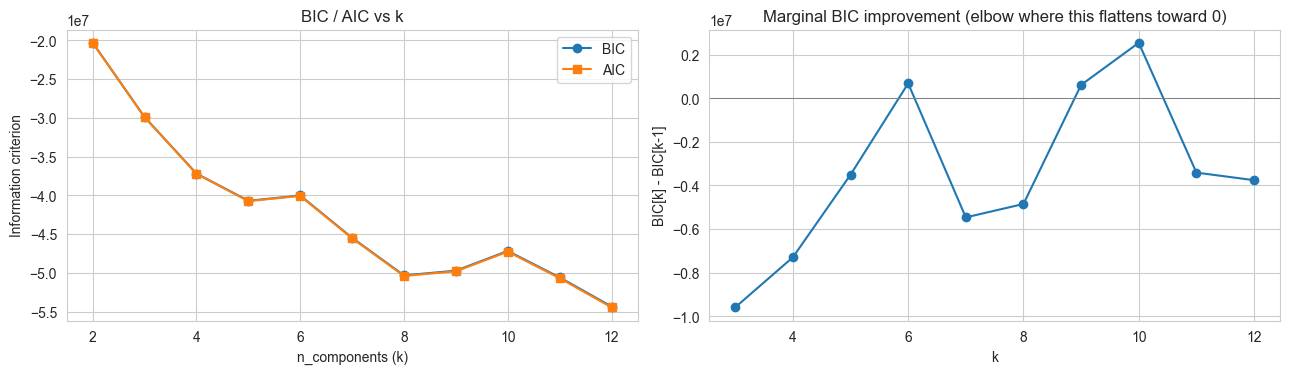

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(sweep_df['k'], sweep_df['BIC'], marker='o', label='BIC')
ax[0].plot(sweep_df['k'], sweep_df['AIC'], marker='s', label='AIC')
ax[0].set_xlabel('n_components (k)')
ax[0].set_ylabel('Information criterion')
ax[0].set_title('BIC / AIC vs k')
ax[0].legend()

bic_deltas = np.diff(sweep_df['BIC'].values)
ax[1].plot(sweep_df['k'].values[1:], bic_deltas, marker='o')
ax[1].axhline(0, color='grey', linewidth=0.7)
ax[1].set_xlabel('k')
ax[1].set_ylabel('BIC[k] - BIC[k-1]')
ax[1].set_title('Marginal BIC improvement (elbow where this flattens toward 0)')
plt.tight_layout()
plt.show()

In [11]:
bic_arr = sweep_df['BIC'].values
k_arr = sweep_df['k'].values

p1 = np.array([k_arr[0], bic_arr[0]])
p2 = np.array([k_arr[-1], bic_arr[-1]])
line_vec = p2 - p1
line_vec_norm = line_vec / np.linalg.norm(line_vec)
distances = []
for i in range(len(k_arr)):
    pt = np.array([k_arr[i], bic_arr[i]]) - p1
    proj = np.dot(pt, line_vec_norm) * line_vec_norm
    distances.append(np.linalg.norm(pt - proj))
elbow_k = int(k_arr[int(np.argmax(distances))])

K_CHOSEN = elbow_k
print(f'Geometric-elbow k = {K_CHOSEN}')
print('Override K_CHOSEN in the next cell if the plot suggests a different value.')

Geometric-elbow k = 5
Override K_CHOSEN in the next cell if the plot suggests a different value.


In [12]:
# Manual override / confirmation. Edit if the elbow plot suggests a different k.
K_CHOSEN = K_CHOSEN
print(f'Final k for GMM fit: {K_CHOSEN}')

Final k for GMM fit: 5


## 4. Bayesian GMM (variational) sanity check

`BayesianGaussianMixture` with a Dirichlet-process prior provides an independent opinion on the effective component count. We give it `n_components=20` as an upper bound and let the prior shrink unused weights toward zero. Components with weight below 1% are treated as effectively unused. If the effective count is far from our BIC choice, document it - usually the truth lies between.

Effective component count (weight > 1%): 14 out of 20 requested.
BIC elbow choice for comparison: k = 5


,component,weight
12,12,0.336464
4,4,0.117405
15,15,0.090702
5,5,0.082782
1,1,0.063755
18,18,0.063245
10,10,0.049479
8,8,0.042753
3,3,0.036965
7,7,0.024196


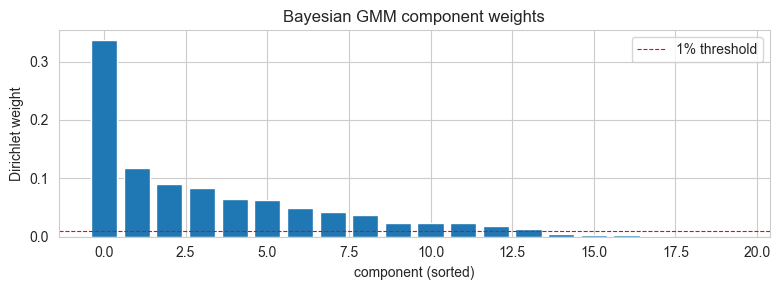

In [13]:
BGMM_MAX_K = 20
bgmm = BayesianGaussianMixture(
    n_components=BGMM_MAX_K,
    covariance_type='full',
    weight_concentration_prior_type='dirichlet_process',
    weight_concentration_prior=1e-2,
    random_state=RANDOM_STATE,
    n_init=1,
    max_iter=300,
    tol=1e-3,
    reg_covar=1e-5,
)
bgmm.fit(X_sample)

weights = bgmm.weights_
effective = int((weights > 0.01).sum())
print(f'Effective component count (weight > 1%): {effective} out of {BGMM_MAX_K} requested.')
print(f'BIC elbow choice for comparison: k = {K_CHOSEN}')
weights_df = pd.DataFrame({'component': range(BGMM_MAX_K), 'weight': weights}).sort_values('weight', ascending=False)
display(weights_df.head(BGMM_MAX_K))

plt.figure(figsize=(8, 3))
plt.bar(range(BGMM_MAX_K), np.sort(weights)[::-1])
plt.axhline(0.01, color='red', linestyle='--', linewidth=0.8, label='1% threshold')
plt.xlabel('component (sorted)')
plt.ylabel('Dirichlet weight')
plt.title('Bayesian GMM component weights')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Final developer-level GMM fit

Refit at the chosen `k` with `n_init=5` on the full active set. The fitted model is pickled to `gmm_artifacts/gmm_developer_v1.joblib` so cluster profiling cells can be re-run without refitting. We persist hard labels, the full `n x k` posterior probability matrix, the max-posterior, and the posterior entropy as a soft-assignment uncertainty score.

In [14]:
gmm = GaussianMixture(
    n_components=K_CHOSEN,
    covariance_type=COV_TYPE,
    random_state=RANDOM_STATE,
    n_init=5,
    max_iter=300,
    tol=1e-3,
    reg_covar=1e-5,
)
gmm.fit(X_scaled)

hard_labels = gmm.predict(X_scaled)
posteriors = gmm.predict_proba(X_scaled)
max_post = posteriors.max(axis=1)
with np.errstate(divide='ignore', invalid='ignore'):
    ent = -np.sum(np.where(posteriors > 0, posteriors * np.log(posteriors), 0.0), axis=1)

print(f'Active developers clustered: {len(hard_labels):,}')
print(f'Cluster sizes:')
for c, n in zip(*np.unique(hard_labels, return_counts=True)):
    print(f'  cluster {c}: {n:,}  ({n / len(hard_labels):.1%})')
print(f'Mean max-posterior: {max_post.mean():.3f}   Mean posterior entropy: {ent.mean():.3f}')

joblib.dump({'gmm': gmm, 'scaler': scaler, 'feature_names': feature_names},
            ARTIFACT_DIR / 'gmm_developer_v1.joblib')
print(f'Saved fit -> {ARTIFACT_DIR / "gmm_developer_v1.joblib"}')

Active developers clustered: 7,660,278
Cluster sizes:
  cluster 0: 4,119,992  (53.8%)
  cluster 1: 896,272  (11.7%)
  cluster 2: 306,724  (4.0%)
  cluster 3: 1,994,848  (26.0%)
  cluster 4: 342,442  (4.5%)
Mean max-posterior: 0.999   Mean posterior entropy: 0.002
Saved fit -> gmm_artifacts\gmm_developer_v1.joblib


In [15]:
active_df['gmm_cluster_id'] = hard_labels
active_df['gmm_max_posterior'] = max_post
active_df['gmm_posterior_entropy'] = ent
for c in range(K_CHOSEN):
    active_df[f'gmm_prob_c{c}'] = posteriors[:, c]

unactivated_df['gmm_cluster_id'] = -1
unactivated_df['gmm_max_posterior'] = 1.0
unactivated_df['gmm_posterior_entropy'] = 0.0
for c in range(K_CHOSEN):
    unactivated_df[f'gmm_prob_c{c}'] = 0.0

result_df = pd.concat([active_df, unactivated_df], axis=0, ignore_index=True)
print(f'Result dataframe rows: {len(result_df):,} (active + unactivated reattached as cluster -1)')

Result dataframe rows: 9,379,190 (active + unactivated reattached as cluster -1)


## 6. Cluster profiling

For each cluster, summarize:

- Centroid in original (pre-scale) feature space.
- Held-out profile columns (`persona`, `dormancy_status`, `final_lifecycle_status`, `developer_effort_level`, `country`, `account_type`).
- Modality composition (lifetime modality counts).
- Visualization: normalized-centroid radar chart, silhouette plot, t-SNE projection.

In [16]:
centroid_orig = active_df.groupby('gmm_cluster_id')[MODEL_FEATURES].mean().T
centroid_z = pd.DataFrame(
    scaler.transform(centroid_orig.T.values),
    index=centroid_orig.columns,
    columns=feature_names,
).T
print('Cluster centroids (z-scored, top variance features):')
top_var_feats = centroid_z.var(axis=1).sort_values(ascending=False).head(15).index
display(centroid_z.loc[top_var_feats].round(2))

Cluster centroids (z-scored, top variance features):


gmm_cluster_id,0,1,2,3,4
lifetime_ngc_download_count,-0.10,-0.10,71.85,-0.07,22.93
lifetime_build_count,0.75,18.30,53.39,-0.39,5.82
lifetime_devzone_download_count,1.44,21.26,39.62,-0.52,-0.72
lifetime_api_count,-0.16,-0.16,14.44,-0.16,30.88
lifetime_discover_count,0.58,3.11,18.13,0.40,28.27
lifetime_champion_count,-0.09,-0.09,21.75,-0.09,1.62
lifetime_forum_count,-0.09,-0.09,15.37,-0.09,-0.09
lifetime_evaluate_count,1.03,4.96,10.33,-0.48,-0.55
activity_velocity_0_30_vs_30_90,NaN,-0.06,4.18,-0.06,4.65
lifetime_bug_count,-0.03,-0.03,5.64,-0.03,-0.03


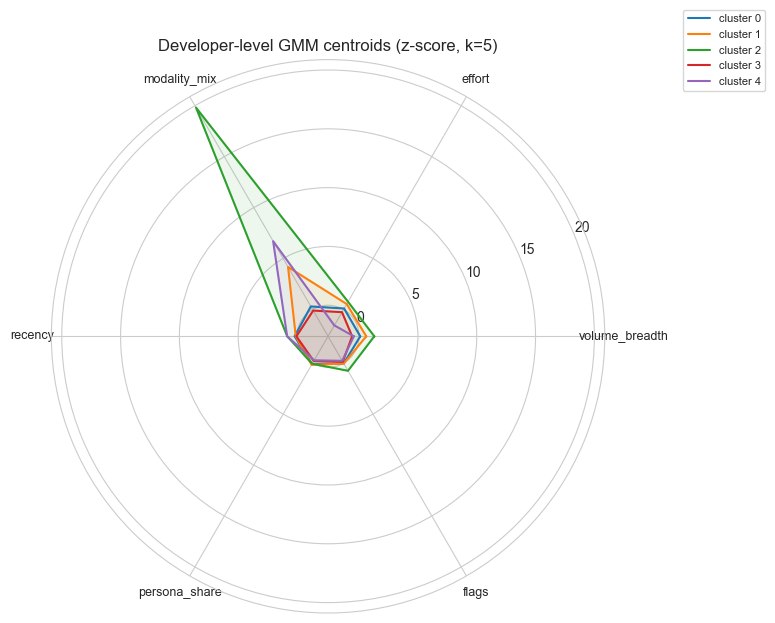

In [17]:
def radar_plot(centroid_z, feature_groups, title):
    group_means = {}
    for gname, feats in feature_groups.items():
        feats_in = [f for f in feats if f in centroid_z.index]
        if feats_in:
            group_means[gname] = centroid_z.loc[feats_in].mean(axis=0)
    radar_df = pd.DataFrame(group_means).T
    angles = np.linspace(0, 2 * np.pi, len(radar_df.index), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    palette = sns.color_palette('tab10', n_colors=len(radar_df.columns))
    for i, cl in enumerate(radar_df.columns):
        vals = radar_df[cl].tolist() + [radar_df[cl].iloc[0]]
        ax.plot(angles, vals, label=f'cluster {cl}', color=palette[i])
        ax.fill(angles, vals, alpha=0.08, color=palette[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_df.index, fontsize=9)
    ax.set_title(title)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    plt.tight_layout()
    plt.show()

feature_groups = {
    'volume_breadth': VOLUME_BREADTH,
    'effort': EFFORT,
    'modality_mix': MODALITY_COUNTS,
    'recency': RECENCY,
    'persona_share': PERSONA_SHARE,
    'flags': FLAGS,
}
radar_plot(centroid_z, feature_groups, f'Developer-level GMM centroids (z-score, k={K_CHOSEN})')

Silhouette (sampled n=50,000): 0.092


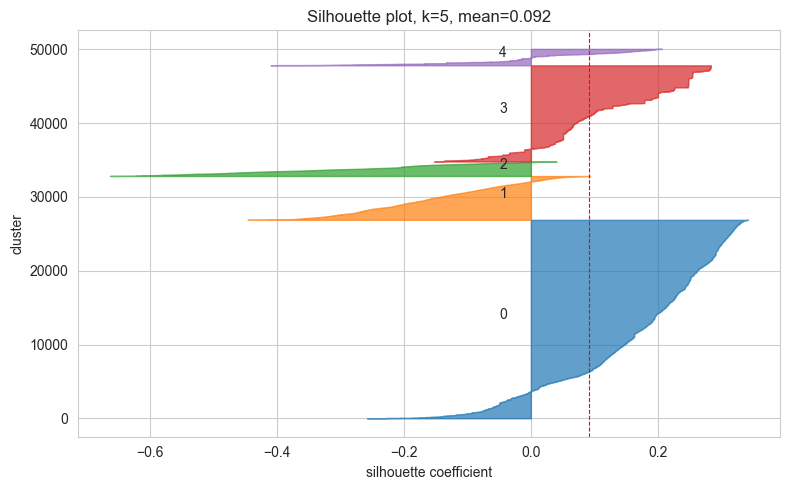

In [18]:
SIL_SAMPLE = 50_000
if len(X_scaled) > SIL_SAMPLE:
    sil_idx = np.random.choice(len(X_scaled), size=SIL_SAMPLE, replace=False)
else:
    sil_idx = np.arange(len(X_scaled))
sil_score = silhouette_score(X_scaled[sil_idx], hard_labels[sil_idx])
sil_samples = silhouette_samples(X_scaled[sil_idx], hard_labels[sil_idx])
print(f'Silhouette (sampled n={len(sil_idx):,}): {sil_score:.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
palette = sns.color_palette('tab10', K_CHOSEN)
for i in range(K_CHOSEN):
    cs = np.sort(sil_samples[hard_labels[sil_idx] == i])
    size = cs.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cs, facecolor=palette[i], edgecolor=palette[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10
ax.axvline(sil_score, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('silhouette coefficient')
ax.set_ylabel('cluster')
ax.set_title(f'Silhouette plot, k={K_CHOSEN}, mean={sil_score:.3f}')
plt.tight_layout()
plt.show()

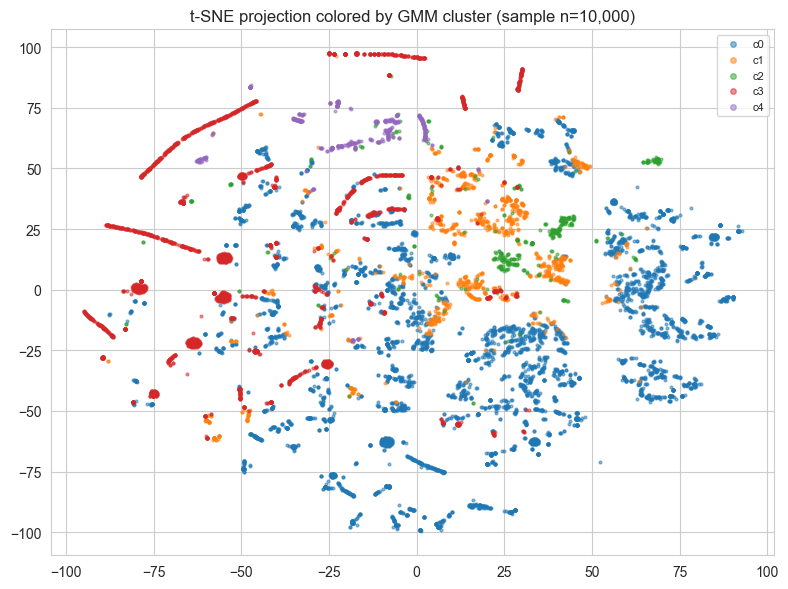

In [19]:
TSNE_SAMPLE = 10_000
tsne_idx = np.random.choice(len(X_scaled), size=min(TSNE_SAMPLE, len(X_scaled)), replace=False)
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca', learning_rate='auto')
embed = tsne.fit_transform(X_scaled[tsne_idx])

plt.figure(figsize=(8, 6))
for c in range(K_CHOSEN):
    m = hard_labels[tsne_idx] == c
    plt.scatter(embed[m, 0], embed[m, 1], s=4, alpha=0.5, label=f'c{c}')
plt.legend(markerscale=2, fontsize=8)
plt.title(f't-SNE projection colored by GMM cluster (sample n={len(tsne_idx):,})')
plt.tight_layout()
plt.show()

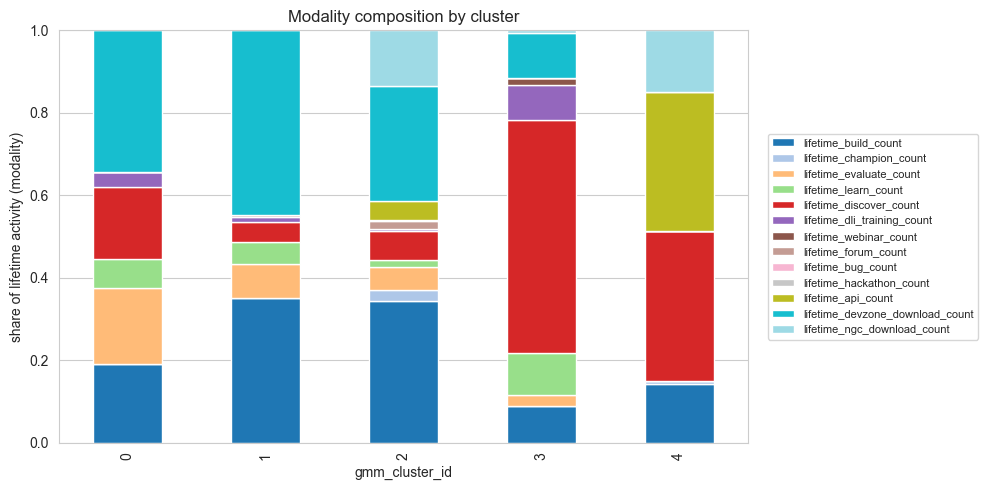

In [20]:
modality_share = active_df.groupby('gmm_cluster_id')[MODALITY_COUNTS].mean()
modality_share = modality_share.div(modality_share.sum(axis=1), axis=0)

modality_share.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20')
plt.ylabel('share of lifetime activity (modality)')
plt.title('Modality composition by cluster')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

In [21]:
for col in PROFILE_COLS:
    if col not in active_df.columns:
        continue
    print(f'\n--- {col} share by cluster ---')
    tab = pd.crosstab(active_df['gmm_cluster_id'], active_df[col], normalize='index')
    display(tab.round(3))


--- persona share by cluster ---


persona,CUDA,GenAI,Learning_Community,Robotics,Simulation,Unknown
gmm_cluster_id,,,,,,
0,0.645,0.151,0.061,0.070,0.040,0.033
1,0.406,0.253,0.091,0.205,0.045,0.000
2,0.328,0.211,0.041,0.229,0.076,0.116
3,0.141,0.468,0.064,0.000,0.131,0.196
4,0.348,0.468,0.000,0.000,0.000,0.184



--- final_lifecycle_status share by cluster ---


final_lifecycle_status,Active_Build,Active_Champion,Active_Discover,Active_Evaluate,Active_Learn,AtRisk_Build,AtRisk_Champion,AtRisk_Discover,AtRisk_Evaluate,AtRisk_Learn,Dormant_Build,Dormant_Champion,Dormant_Discover,Dormant_Evaluate,Dormant_Learn,FreeEmail,Tourist
gmm_cluster_id,,,,,,,,,,,,,,,,,
0,0.000,0.000,0.000,0.000,0.000,0.036,0.000,0.001,0.004,0.021,0.203,0.000,0.004,0.050,0.070,0.023,0.588
1,0.143,0.000,0.011,0.024,0.077,0.044,0.000,0.004,0.006,0.027,0.150,0.000,0.013,0.027,0.072,0.013,0.390
2,0.229,0.054,0.016,0.018,0.029,0.076,0.034,0.002,0.005,0.009,0.148,0.144,0.006,0.011,0.014,0.012,0.191
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.002,0.000,0.997
4,0.000,0.000,0.372,0.000,0.000,0.000,0.000,0.072,0.000,0.000,0.000,0.000,0.100,0.000,0.000,0.000,0.456



--- behavior_journey_stage_30d share by cluster ---


...

developer_effort_rank,1,2,3,4
gmm_cluster_id,,,,
0,0.456,0.420,0.124,0.000
1,0.119,0.073,0.435,0.373
2,0.149,0.116,0.278,0.457
3,0.685,0.156,0.067,0.091
4,0.563,0.023,0.096,0.318



--- country share by cluster ---


country,AFGHANISTAN,ALAND ISLANDS,ALBANIA,ALGERIA,AMERICAN SAMOA,ANDORRA,ANGOLA,ANGUILLA,ANTARCTICA,ANTIGUA AND BARBUDA,...,VANUATU,VATICAN CITY STATE,VENEZUELA,VIET NAM,"VIRGIN ISLANDS, U.S.",WALLIS AND FUTUNA,WESTERN SAHARA,YEMEN,ZAMBIA,ZIMBABWE
gmm_cluster_id,,,,,,,,,,,,,,,,,,,,,
0,0.004,0.002,0.002,0.003,0.001,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000,0.010,0.0,0.0,0.0,0.0,0.0,0.0
1,0.002,0.001,0.001,0.002,0.001,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000,0.011,0.0,0.0,0.0,0.0,0.0,0.0
2,0.002,0.001,0.001,0.001,0.001,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000,0.009,0.0,0.0,0.0,0.0,0.0,0.0
3,0.004,0.003,0.002,0.003,0.001,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.001,0.010,0.0,0.0,0.0,0.0,0.0,0.0
4,0.007,0.004,0.003,0.002,0.001,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000,0.004,0.0,0.0,0.0,0.0,0.0,0.0



--- account_type share by cluster ---


account_type,enterprise,enterprise;startup,enterprise;university,startup,startup;university,university,unknown
gmm_cluster_id,,,,,,,
0,0.076,0.001,0.003,0.025,0.002,0.320,0.573
1,0.100,0.001,0.002,0.040,0.002,0.253,0.602
2,0.133,0.002,0.002,0.049,0.002,0.162,0.650
3,0.077,0.001,0.001,0.023,0.001,0.159,0.737
4,0.012,0.000,0.000,0.006,0.000,0.021,0.961


### 6.1 Assign human-readable cluster labels

After reviewing the centroid radar, modality stack, and profile cross-tabs above, fill in the `CLUSTER_LABELS` dict below. The labels are persisted as a `gmm_cluster_label` column on the DuckDB output table so downstream notebooks can reference them by meaning rather than integer id.

In [22]:
CLUSTER_LABELS = {c: f'cluster_{c}' for c in range(K_CHOSEN)}
CLUSTER_LABELS[-1] = 'unactivated'

# Edit the strings above with descriptive names like 'high_effort_builder',
# 'casual_learner', 'recent_evaluator', etc. once you have read the profile output.

result_df['gmm_cluster_label'] = result_df['gmm_cluster_id'].map(CLUSTER_LABELS)
display(result_df['gmm_cluster_label'].value_counts())

gmm_cluster_label
cluster_0      4119992
cluster_3      1994848
unactivated    1718912
cluster_1       896272
cluster_4       342442
cluster_2       306724
Name: count, dtype: int64

## 7. Persist developer-level GMM output to DuckDB

Write `dev_gmm_clusters_v1`. The schema is the developer id, hard cluster id, human label, max-posterior, posterior entropy, and one probability column per component. Probabilities are a real GMM advantage over k-means and HMM's Viterbi labels - downstream notebooks can use them for soft membership or uncertainty filtering.

In [23]:
out_cols = [ID_COL, 'gmm_cluster_id', 'gmm_cluster_label', 'gmm_max_posterior', 'gmm_posterior_entropy'] + [f'gmm_prob_c{c}' for c in range(K_CHOSEN)]
out_df = result_df[out_cols].copy()

con.register('out_df_view', out_df)
con.execute('CREATE OR REPLACE TABLE dev_gmm_clusters_v1 AS SELECT * FROM out_df_view')
con.unregister('out_df_view')

display(con.execute('SELECT COUNT(*) AS n_rows FROM dev_gmm_clusters_v1').fetchdf())
display(con.execute('SELECT gmm_cluster_label, COUNT(*) AS n FROM dev_gmm_clusters_v1 GROUP BY 1 ORDER BY n DESC').fetchdf())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_rows
0,9379190


,gmm_cluster_label,n
0,cluster_0,4119992
1,cluster_3,1994848
2,unactivated,1718912
3,cluster_1,896272
4,cluster_4,342442
5,cluster_2,306724


## 8. Weekly-emission GMM

This run is the direct apples-to-apples comparison with the HMM, which emits one Gaussian per state per week. We fit on `dev_weekly_features_v2` (one row per developer-week) using the count features the HMM also uses. After fitting, we aggregate weekly cluster assignments back to the developer level as:

- **Modal cluster**: the most-frequent weekly cluster for that developer.
- **Soft-prob average**: mean posterior probability across all weeks for that developer (a soft membership profile).
- **Cluster sequence string**: ordered string of weekly cluster ids (for temporal-coherence comparison with HMM).

In [24]:
WEEKLY_FEATURES = [
    'activity_count_total', 'activity_score_sum', 'unique_activity_types',
    'build_count', 'champion_count', 'high_effort_count', 'product_use_count',
]

weekly_cols = con.execute('PRAGMA table_info(dev_weekly_features_v2)').fetchdf()['name'].tolist()
WEEKLY_FEATURES = [c for c in WEEKLY_FEATURES if c in weekly_cols]
print(f'Weekly feature columns used: {WEEKLY_FEATURES}')

weekly_df = con.execute(
    f"SELECT developer_id, week_start, {', '.join(WEEKLY_FEATURES)} FROM dev_weekly_features_v2"
).fetchdf()
print(f'Weekly rows: {len(weekly_df):,}')

Weekly feature columns used: ['activity_count_total', 'activity_score_sum', 'unique_activity_types', 'build_count', 'champion_count', 'high_effort_count', 'product_use_count']


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Weekly rows: 14,908,480


Weekly sweep sample: (500000, 7)
weekly k= 2  BIC=-9106058.1  AIC=-9106847.7
weekly k= 3  BIC=-12655679.9  AIC=-12656870.0
weekly k= 4  BIC=-12829867.2  AIC=-12831457.7
weekly k= 5  BIC=-13230639.0  AIC=-13232629.9
weekly k= 6  BIC=-14728919.5  AIC=-14731310.8
weekly k= 7  BIC=-16432432.8  AIC=-16435224.5
weekly k= 8  BIC=-18422906.8  AIC=-18426098.9
weekly k= 9  BIC=-17534071.1  AIC=-17537663.6
weekly k=10  BIC=-17844426.5  AIC=-17848419.4
weekly k=11  BIC=-17914268.2  AIC=-17918661.5
weekly k=12  BIC=-19208934.6  AIC=-19213728.4


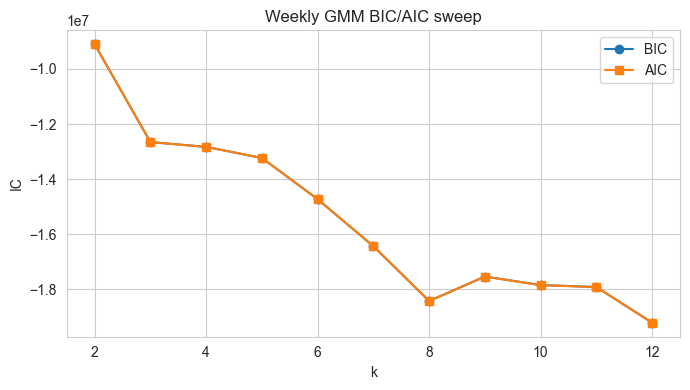

In [25]:
Xw = weekly_df[WEEKLY_FEATURES].fillna(0).clip(lower=0).copy()
for col in WEEKLY_FEATURES:
    Xw[col] = np.log1p(Xw[col])
weekly_scaler = StandardScaler()
Xw_scaled = weekly_scaler.fit_transform(Xw.values)

WEEKLY_SAMPLE = 500_000
if len(Xw_scaled) > WEEKLY_SAMPLE:
    w_idx = np.random.choice(len(Xw_scaled), size=WEEKLY_SAMPLE, replace=False)
    Xw_sub = Xw_scaled[w_idx]
else:
    Xw_sub = Xw_scaled
print(f'Weekly sweep sample: {Xw_sub.shape}')

weekly_bic, weekly_aic = [], []
for k in K_RANGE:
    gw = GaussianMixture(n_components=k, covariance_type='full', random_state=RANDOM_STATE,
                        n_init=2, max_iter=200, reg_covar=1e-5)
    gw.fit(Xw_sub)
    weekly_bic.append(gw.bic(Xw_sub))
    weekly_aic.append(gw.aic(Xw_sub))
    print(f'weekly k={k:2d}  BIC={weekly_bic[-1]:.1f}  AIC={weekly_aic[-1]:.1f}')

plt.figure(figsize=(7, 4))
plt.plot(K_RANGE, weekly_bic, marker='o', label='BIC')
plt.plot(K_RANGE, weekly_aic, marker='s', label='AIC')
plt.xlabel('k')
plt.ylabel('IC')
plt.title('Weekly GMM BIC/AIC sweep')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
weekly_bic_arr = np.array(weekly_bic)
p1w = np.array([K_RANGE[0], weekly_bic_arr[0]])
p2w = np.array([K_RANGE[-1], weekly_bic_arr[-1]])
vw = p2w - p1w
vw_n = vw / np.linalg.norm(vw)
dists_w = []
for i in range(len(K_RANGE)):
    pt = np.array([K_RANGE[i], weekly_bic_arr[i]]) - p1w
    proj = np.dot(pt, vw_n) * vw_n
    dists_w.append(np.linalg.norm(pt - proj))
K_WEEKLY = int(K_RANGE[int(np.argmax(dists_w))])
print(f'Weekly geometric-elbow k = {K_WEEKLY}. Override below if necessary.')
K_WEEKLY = K_WEEKLY

Weekly geometric-elbow k = 8. Override below if necessary.


In [27]:
gmm_weekly = GaussianMixture(
    n_components=K_WEEKLY,
    covariance_type='full',
    random_state=RANDOM_STATE,
    n_init=3,
    max_iter=300,
    reg_covar=1e-5,
)
gmm_weekly.fit(Xw_scaled)
weekly_labels = gmm_weekly.predict(Xw_scaled)
weekly_post = gmm_weekly.predict_proba(Xw_scaled)
weekly_max = weekly_post.max(axis=1)

weekly_df['gmm_weekly_cluster_id'] = weekly_labels
weekly_df['gmm_weekly_max_posterior'] = weekly_max
for c in range(K_WEEKLY):
    weekly_df[f'gmm_weekly_prob_c{c}'] = weekly_post[:, c]

joblib.dump({'gmm_weekly': gmm_weekly, 'scaler': weekly_scaler, 'feature_names': WEEKLY_FEATURES},
            ARTIFACT_DIR / 'gmm_weekly_v1.joblib')
print(f'Weekly cluster sizes:')
for c, n in zip(*np.unique(weekly_labels, return_counts=True)):
    print(f'  c{c}: {n:,} ({n / len(weekly_labels):.1%})')

Weekly cluster sizes:
  c0: 4,425,645 (29.7%)
  c1: 3,579,786 (24.0%)
  c2: 409,107 (2.7%)
  c3: 30,310 (0.2%)
  c4: 4,519,991 (30.3%)
  c5: 768,423 (5.2%)
  c6: 863,387 (5.8%)
  c7: 311,831 (2.1%)


In [28]:
weekly_out_cols = ['developer_id', 'week_start', 'gmm_weekly_cluster_id', 'gmm_weekly_max_posterior'] + [f'gmm_weekly_prob_c{c}' for c in range(K_WEEKLY)]
weekly_out = weekly_df[weekly_out_cols].copy()
con.register('weekly_out_view', weekly_out)
con.execute('CREATE OR REPLACE TABLE dev_gmm_weekly_clusters_v1 AS SELECT * FROM weekly_out_view')
con.unregister('weekly_out_view')
display(con.execute('SELECT COUNT(*) AS n_rows FROM dev_gmm_weekly_clusters_v1').fetchdf())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_rows
0,14908480


In [31]:
# 1) Modal cluster — vectorized via value_counts, no per-group Python lambda
modal = (
    weekly_df.groupby(['developer_id', 'gmm_weekly_cluster_id']).size()
    .reset_index(name='n')
    .sort_values(['developer_id', 'n'], ascending=[True, False])
    .drop_duplicates('developer_id')
    .set_index('developer_id')['gmm_weekly_cluster_id']
    .rename('modal_weekly_cluster')
)

# 2) Soft-prob average — cheap, leave as is
prob_cols = [f'gmm_weekly_prob_c{c}' for c in range(K_WEEKLY)]
soft = weekly_df.groupby('developer_id')[prob_cols].mean()

# 3) Sequence string — only sort the 3 cols we need, and build the string with .astype(str) once
seq_df = weekly_df[['developer_id', 'week_start', 'gmm_weekly_cluster_id']].sort_values(
    ['developer_id', 'week_start'], kind='mergesort'
)
seq_df['c_str'] = seq_df['gmm_weekly_cluster_id'].astype('int8').astype(str)
seq = seq_df.groupby('developer_id', sort=False)['c_str'].agg(''.join).rename('weekly_cluster_sequence')
del seq_df

dev_weekly_summary = pd.concat([modal, soft, seq], axis=1).reset_index()
print(f'Developer-level rollup of weekly clusters: {len(dev_weekly_summary):,} developers.')
display(dev_weekly_summary.head(5))


Developer-level rollup of weekly clusters: 7,660,278 developers.


,developer_id,modal_weekly_cluster,gmm_weekly_prob_c0,gmm_weekly_prob_c1,gmm_weekly_prob_c2,gmm_weekly_prob_c3,gmm_weekly_prob_c4,gmm_weekly_prob_c5,gmm_weekly_prob_c6,gmm_weekly_prob_c7,weekly_cluster_sequence
0,0003027cbcc9f926a435232e311b3a5ffcbb0d16668d12...,4,0.0,0.000003,1.502490e-194,9.626006e-18,0.999997,0.0,0.0,1.449126e-13,4
1,0004f9e31d24919fec148cbee1fe8cc879787dab762fe3...,4,0.0,0.000003,1.502490e-194,9.626006e-18,0.999997,0.0,0.0,1.449126e-13,4
2,0007b08ac0400b0b96687e36773ec578e3431cc906f384...,0,0.5,0.500000,3.957231e-54,2.947301e-12,0.000000,0.0,0.0,2.947823e-08,01
3,00098092abecb2020544f7de05cd2af6957d8ef6a4dc76...,4,0.0,0.000003,1.502490e-194,9.626006e-18,0.999997,0.0,0.0,1.449126e-13,4
4,000ae897c03cbe99753401fef9af378cd335de98a71140...,4,0.0,0.000003,1.502490e-194,9.626006e-18,0.999997,0.0,0.0,1.449126e-13,4


In [35]:
con.close()
print('DuckDB connection closed. Notebook complete.')

DuckDB connection closed. Notebook complete.
